In [1]:
import os
os.chdir(r'C:\Users\pc\OneDrive\Desktop\credit-risk-dashboard\notebooks')
print("Working directory:", os.getcwd())

Working directory: C:\Users\pc\OneDrive\Desktop\credit-risk-dashboard\notebooks


In [2]:
import sys
print(sys.executable)

c:\Users\pc\AppData\Local\Programs\Python\Python311\python.exe


In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import xgboost as xgb
import pickle

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

print("✅ All imports successful")

✅ All imports successful


In [4]:
DB_PATH = r'C:\Users\pc\OneDrive\Desktop\credit-risk-dashboard\data\credit_risk.db'

con = duckdb.connect(DB_PATH)

# Load from risk_segments — the final clean table
df = con.execute("SELECT * FROM risk_segments").df()

con.close()

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nDefault rate: {df['is_default'].mean()*100:.2f}%")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (149986, 22)

Columns:
['is_default', 'age', 'monthly_income', 'num_dependents', 'revolving_util', 'debt_ratio', 'open_credit_lines', 'real_estate_loans', 'late_30_59', 'late_60_89', 'late_90_plus', 'age_band', 'income_band', 'total_late_payments', 'ever_seriously_delinquent', 'high_util_flag', 'high_debt_flag', 'income_per_dependent', 'estimated_monthly_debt', 'row_num', 'rule_risk_score', 'risk_segment']

Default rate: 6.68%

First 3 rows:


,is_default,age,monthly_income,num_dependents,revolving_util,debt_ratio,open_credit_lines,real_estate_loans,late_30_59,late_60_89,...,income_band,total_late_payments,ever_seriously_delinquent,high_util_flag,high_debt_flag,income_per_dependent,estimated_monthly_debt,row_num,rule_risk_score,risk_segment
0,0,69,4304.0,0.0,0.413435,0.073403,6,0,0,0,...,$4-6k,0,0,0,0,4304.0,315.93,1,-5.0,Low Risk
1,0,30,6031.0,1.0,0.393811,0.363727,15,2,0,0,...,$6-10k,0,0,0,0,6031.0,2193.64,2,8.0,Low Risk
2,0,48,3904.0,0.0,0.054014,0.093982,15,0,0,0,...,$2-4k,0,0,0,0,3904.0,366.91,3,2.0,Low Risk


In [5]:
FEATURES = [
    'age',
    'monthly_income',
    'num_dependents',
    'revolving_util',
    'debt_ratio',
    'open_credit_lines',
    'real_estate_loans',
    'late_30_59',
    'late_60_89',
    'late_90_plus',
    'total_late_payments',
    'ever_seriously_delinquent',
    'high_util_flag',
    'high_debt_flag',
    'income_per_dependent',
    'estimated_monthly_debt'
]

TARGET = 'is_default'

# Drop rows with any nulls in feature columns
df_model = df[FEATURES + [TARGET]].dropna()

print(f"Rows before dropna: {len(df):,}")
print(f"Rows after dropna:  {len(df_model):,}")
print(f"Rows dropped:       {len(df) - len(df_model):,}")
print(f"\nTarget distribution:")
print(df_model[TARGET].value_counts())
print(f"\nClass imbalance ratio: {df_model[TARGET].value_counts()[0] / df_model[TARGET].value_counts()[1]:.1f} : 1")

Rows before dropna: 149,986
Rows after dropna:  149,986
Rows dropped:       0

Target distribution:
is_default
0    139961
1     10025
Name: count, dtype: int64

Class imbalance ratio: 14.0 : 1


In [6]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # keeps default rate same in train and test
)

print(f"Train size: {X_train.shape[0]:,} rows")
print(f"Test size:  {X_test.shape[0]:,} rows")
print(f"\nTrain default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate:  {y_test.mean()*100:.2f}%")
# Both should be ~6.7% — confirms stratify worked

Train size: 119,988 rows
Test size:  29,998 rows

Train default rate: 6.68%
Test default rate:  6.68%


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # use same scaler — never fit on test

print("✅ Features scaled")
print(f"Mean of first feature (train): {X_train_scaled[:, 0].mean():.4f}  ← should be ~0")
print(f"Std  of first feature (train): {X_train_scaled[:, 0].std():.4f}   ← should be ~1")

✅ Features scaled
Mean of first feature (train): -0.0000  ← should be ~0
Std  of first feature (train): 1.0000   ← should be ~1


In [8]:
print("Training Logistic Regression...")

lr = LogisticRegression(
    class_weight='balanced',  # handles 14:1 imbalance
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

# Predictions
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr.predict(X_test_scaled)

# Metrics
lr_auc  = roc_auc_score(y_test, lr_probs)
lr_gini = 2 * lr_auc - 1

print(f"\n✅ Logistic Regression trained")
print(f"   AUC:  {lr_auc:.4f}")
print(f"   Gini: {lr_gini:.4f}  ← industry standard metric")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_preds))

Training Logistic Regression...

✅ Logistic Regression trained
   AUC:  0.8488
   Gini: 0.6976  ← industry standard metric

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27993
           1       0.21      0.74      0.33      2005

    accuracy                           0.79     29998
   macro avg       0.59      0.77      0.60     29998
weighted avg       0.93      0.79      0.84     29998



In [9]:
# Calculate imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"scale_pos_weight = {ratio:.1f}  (neg/pos ratio)")

print("\nTraining XGBoost...")

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=ratio,   # handles class imbalance automatically
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predictions
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)

# Metrics
xgb_auc  = roc_auc_score(y_test, xgb_probs)
xgb_gini = 2 * xgb_auc - 1

print(f"\n✅ XGBoost trained")
print(f"   AUC:  {xgb_auc:.4f}")
print(f"   Gini: {xgb_gini:.4f}  ← industry standard metric")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_preds))

scale_pos_weight = 14.0  (neg/pos ratio)

Training XGBoost...

✅ XGBoost trained
   AUC:  0.8604
   Gini: 0.7208  ← industry standard metric

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27993
           1       0.21      0.76      0.33      2005

    accuracy                           0.79     29998
   macro avg       0.60      0.78      0.61     29998
weighted avg       0.93      0.79      0.84     29998



In [10]:
print("=" * 45)
print(f"{'Model':<25} {'AUC':>8} {'Gini':>8}")
print("=" * 45)
print(f"{'Logistic Regression':<25} {lr_auc:>8.4f} {lr_gini:>8.4f}")
print(f"{'XGBoost':<25} {xgb_auc:>8.4f} {xgb_gini:>8.4f}")
print("=" * 45)
print("\nGini interpretation:")
print("  > 0.6  = Good model")
print("  > 0.7  = Strong model")
print("  > 0.8  = Excellent model")

Model                          AUC     Gini
Logistic Regression         0.8488   0.6976
XGBoost                     0.8604   0.7208

Gini interpretation:
  > 0.6  = Good model
  > 0.7  = Strong model
  > 0.8  = Excellent model


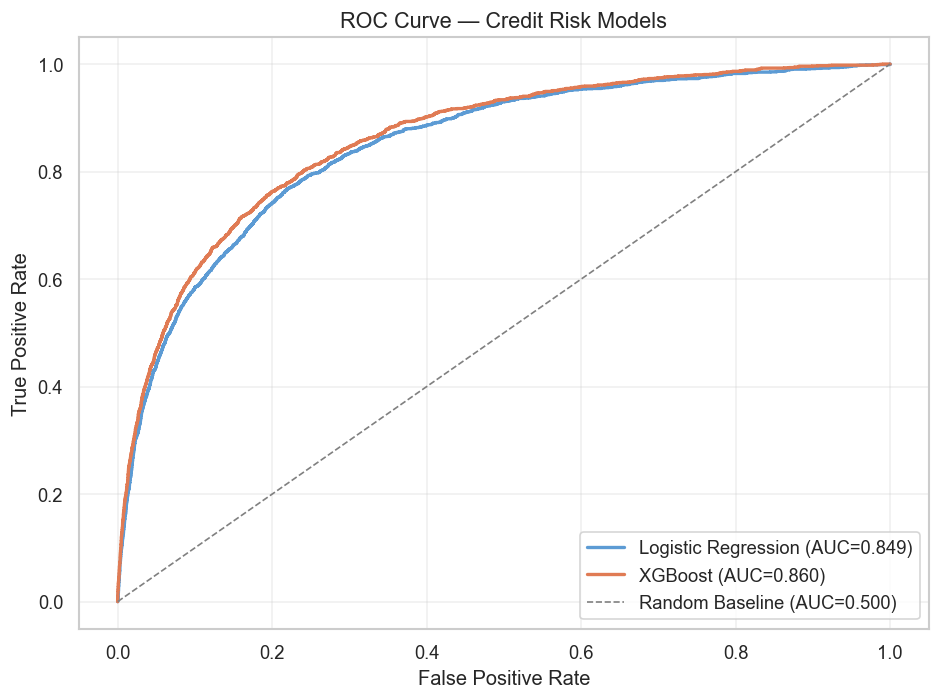

✅ Saved roc_curve.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
ax.plot(lr_fpr, lr_tpr,
        label=f'Logistic Regression (AUC={lr_auc:.3f})',
        color='#5C9BD4', linewidth=2)

# XGBoost ROC
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
ax.plot(xgb_fpr, xgb_tpr,
        label=f'XGBoost (AUC={xgb_auc:.3f})',
        color='#E07B54', linewidth=2)

# Random baseline
ax.plot([0, 1], [0, 1],
        linestyle='--', color='gray',
        label='Random Baseline (AUC=0.500)', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Credit Risk Models', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/roc_curve.png')
plt.show()
print("✅ Saved roc_curve.png")

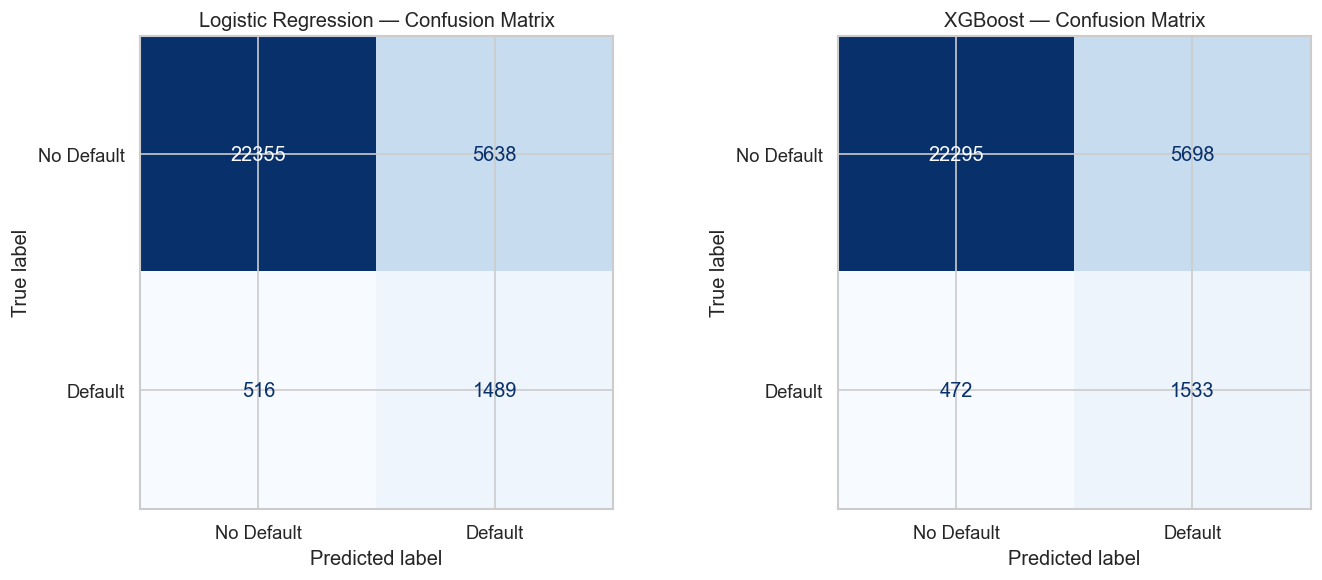

✅ Saved confusion_matrix.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [lr_preds, xgb_preds],
    ['Logistic Regression', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Default', 'Default']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()
print("✅ Saved confusion_matrix.png")

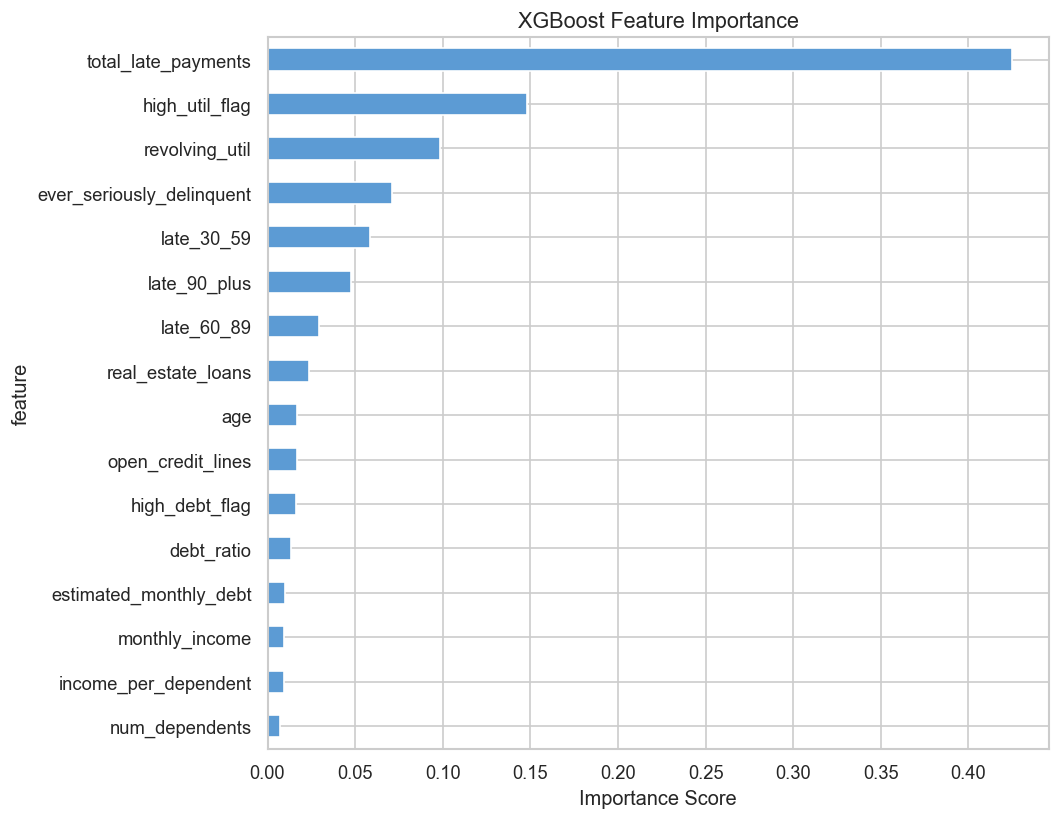

✅ Saved feature_importance.png

Top 5 most important features:
                  feature  importance
      total_late_payments    0.424644
           high_util_flag    0.147883
           revolving_util    0.098443
ever_seriously_delinquent    0.071019
               late_30_59    0.058394


In [13]:
importance_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
importance_df.plot(
    kind='barh', x='feature', y='importance',
    ax=ax, color='#5C9BD4', edgecolor='white', legend=False
)
ax.set_title('XGBoost Feature Importance', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png')
plt.show()
print("✅ Saved feature_importance.png")

print("\nTop 5 most important features:")
print(importance_df.tail(5)[['feature', 'importance']].iloc[::-1].to_string(index=False))

In [14]:
os.makedirs('../app', exist_ok=True)

# Save XGBoost model
with open('../app/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save Logistic Regression model
with open('../app/lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

# Save scaler (needed for logistic regression predictions)
with open('../app/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature list (so Streamlit knows exact column order)
with open('../app/features.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print("✅ Models saved to app/ folder:")
print("   app/xgb_model.pkl")
print("   app/lr_model.pkl")
print("   app/scaler.pkl")
print("   app/features.pkl")

✅ Models saved to app/ folder:
   app/xgb_model.pkl
   app/lr_model.pkl
   app/scaler.pkl
   app/features.pkl


In [15]:
# Add PD scores to test set — Streamlit dashboard will use this
df_scores = X_test.copy()
df_scores['is_default']   = y_test.values
df_scores['pd_score_lr']  = lr_probs
df_scores['pd_score_xgb'] = xgb_probs

# Risk segment based on XGBoost PD score
df_scores['ml_risk_segment'] = pd.cut(
    df_scores['pd_score_xgb'],
    bins=[0, 0.1, 0.3, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Save to DuckDB
DB_PATH = r'C:\Users\pc\OneDrive\Desktop\credit-risk-dashboard\data\credit_risk.db'
con = duckdb.connect(DB_PATH)
con.execute("DROP TABLE IF EXISTS model_scores")
con.execute("CREATE TABLE model_scores AS SELECT * FROM df_scores")

count = con.execute("SELECT COUNT(*) FROM model_scores").fetchone()[0]
print(f"✅ model_scores table created with {count:,} rows")

print("\nRisk segment distribution:")
print(con.execute("""
    SELECT ml_risk_segment, 
           COUNT(*) as customers,
           ROUND(AVG(is_default)*100, 2) as actual_default_rate_pct
    FROM model_scores
    GROUP BY ml_risk_segment
    ORDER BY actual_default_rate_pct DESC
""").df())

con.close()

✅ model_scores table created with 29,998 rows

Risk segment distribution:
  ml_risk_segment  customers  actual_default_rate_pct
0       High Risk      12250                    14.62
1     Medium Risk      10594                     1.62
2        Low Risk       7154                     0.59


In [16]:
print("=" * 50)
print("MODELING COMPLETE — SUMMARY")
print("=" * 50)
print(f"\nDataset:  {len(df_model):,} rows | {len(FEATURES)} features")
print(f"Train:    {len(X_train):,} rows")
print(f"Test:     {len(X_test):,} rows")
print(f"\nModel Performance:")
print(f"  Logistic Regression → AUC: {lr_auc:.4f} | Gini: {lr_gini:.4f}")
print(f"  XGBoost             → AUC: {xgb_auc:.4f} | Gini: {xgb_gini:.4f}")
print(f"\nFiles saved:")
print(f"  app/xgb_model.pkl")
print(f"  app/lr_model.pkl")
print(f"  app/scaler.pkl")
print(f"  app/features.pkl")
print(f"\nDuckDB tables ready:")
print(f"  main.model_scores  ← ML scores for dashboard")
print(f"  main.risk_segments ← Rule based segments")
print(f"  main.portfolio_summary ← Aggregated analytics")
print("=" * 50)
print("\n✅ Ready for Streamlit dashboard (Step 4)")

MODELING COMPLETE — SUMMARY

Dataset:  149,986 rows | 16 features
Train:    119,988 rows
Test:     29,998 rows

Model Performance:
  Logistic Regression → AUC: 0.8488 | Gini: 0.6976
  XGBoost             → AUC: 0.8604 | Gini: 0.7208

Files saved:
  app/xgb_model.pkl
  app/lr_model.pkl
  app/scaler.pkl
  app/features.pkl

DuckDB tables ready:
  main.model_scores  ← ML scores for dashboard
  main.risk_segments ← Rule based segments
  main.portfolio_summary ← Aggregated analytics

✅ Ready for Streamlit dashboard (Step 4)
